In [3]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# # import  settings
# import plot_settings
# plot_settings.apply()

In [12]:
# load model
model = pybamm.lithium_ion.SPM()

# create geometry
geometry = model.default_geometry

# load parameter values and process model and geometry
param = pybamm.ParameterValues("Chen2020")

def my_current(t):
    return 1

param["Current function [A]"] = 1 

param.process_geometry(geometry)
param.process_model(model)

# create simulation
simulation = pybamm.Simulation(model, parameter_values=param)

# set mesh
var = pybamm.standard_spatial_vars
var_pts = {var.x_n: 30, var.x_s: 30, var.x_p: 30, var.r_n: 10, var.r_p: 10}
mesh = pybamm.Mesh(geometry, model.default_submesh_types, var_pts)

# discretise model
disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model);

In [13]:
# solve model
t_eval = [0, 3600]
solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
solution = solver.solve(model, t_eval)

In [15]:
# variables

model.print_parameter_info()

┌───────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Parameter                                                 │ Type of parameter                                                                                                                                                                                           │
├───────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Positive electrode Bruggeman coefficient (electrolyte)    │ Parameter                                                                                                                             

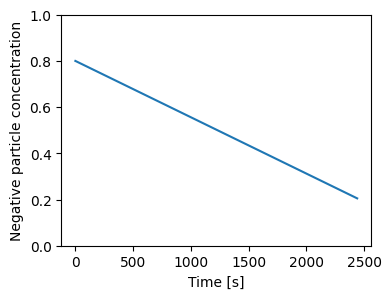

In [7]:
c_s_n = solution["R-averaged negative particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

def plot_concentrations(t):
    fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))
    
    # Evaluate concentration at specific time and x position (returns values at all r points)
    c_vals = c_s_n(t=t, x=x[0]) # shape (nt, nx)
    
    ax1.plot(t, c_vals)
    ax1.set_ylabel("Negative particle concentration")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylim(0, 1)

plot_concentrations(t=t)

Text(0.5, 1.0, 'Negative particle concentration at t')

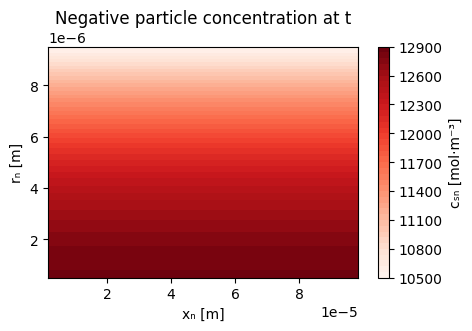

In [8]:
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 1800
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))

# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
r2d = r_n[..., ti]    # shape (nr, nx)
x2d = x_n[..., ti]    # shape (nx,)

# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[..., ti]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(5, 3))
X, R = np.meshgrid(x2d, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(X, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="cₛₙ [mol·m⁻³]")

ax.set_xlabel("xₙ [m]")
ax.set_ylabel("rₙ [m]")
ax.set_title(f"Negative particle concentration at t")

(10, 35)


Text(0.5, 1.0, 'Negative particle concentration at t')

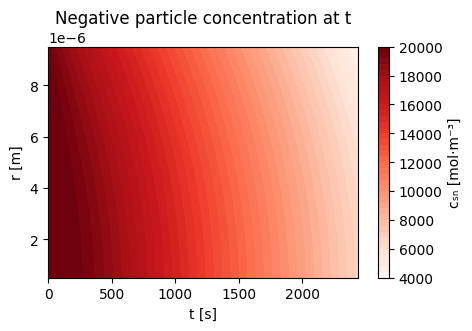

In [9]:
# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"].entries
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Extract r grid and x grid at that time
x1 = 2
r2d = r_n[:, x1, :]    # shape (nr, nx)
# Concentration is (nr, nx, nt) as well
c2d = c_s_n[:, x1, :]  # shape (nr, nx)

print(c2d.shape)

# Now plot
fig, ax = plt.subplots(figsize=(5, 3))
T, R = np.meshgrid(t_vals, r2d[:, 0])  # r varies along rows, x along columns
cs = ax.contourf(T, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="cₛₙ [mol·m⁻³]")

ax.set_xlabel("t [s]")
ax.set_ylabel("r [m]")
ax.set_title(f"Negative particle concentration at t")

(10, 30, 35)
(30, 35)
(35,)


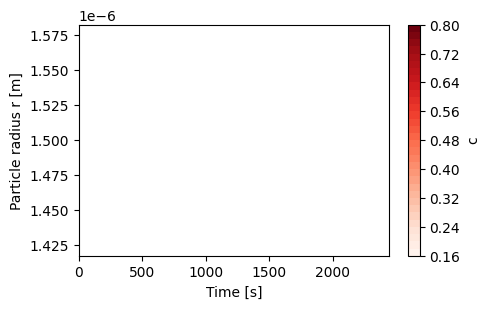

In [10]:
c = solution["Negative particle surface concentration"].entries
r = solution["r_n [m]"].entries
t = solution["Time [s]"].entries

r_index = 1  # choose one electrode location

print(r.shape)  # (nr, nx, nt)
print(c.shape)  # (nx, nt)
print(t.shape)  # (nt,)

# slice → now 2D
C = c[:, :]   # (nx, nt)
R = r[r_index, :, :]   # (nx, nt)

T, R = np.meshgrid(t, R[:,0])

fig, ax = plt.subplots(figsize=(5,3))
cs = ax.contourf(T, R, C, levels=40, cmap="Reds")

fig.colorbar(cs, ax=ax, label="c")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Particle radius r [m]")
plt.show()

(35,) (30, 35)


Text(0.5, 0, 'Time [s]')

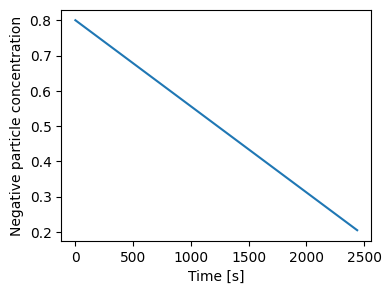

In [11]:
c_s_n = solution["R-averaged negative particle concentration"].entries
c = np.mean(c_s_n, axis=0)  # SPM, same concentration for all x
r_n = solution["r_n [m]"].entries[:, 0, 1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))

print(t.shape, c_s_n.shape)
ax1.plot(t, c_s_n[8, :])
ax1.set_ylabel("Negative particle concentration")
ax1.set_xlabel("Time [s]")

In [12]:
npc = solution.observe(model.variables["Negative particle concentration"])

t = np.linspace(0, solution["Time [s]"].entries[-1], solution["Time [s]"].entries)
print(npc(t)[0,0,:])

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
print(solution["r_n [m]"].entries[:,0,0])

[5.0e-07 1.5e-06 2.5e-06 3.5e-06 4.5e-06 5.5e-06 6.5e-06 7.5e-06 8.5e-06
 9.5e-06]
